Dataset shape: (34272, 207)


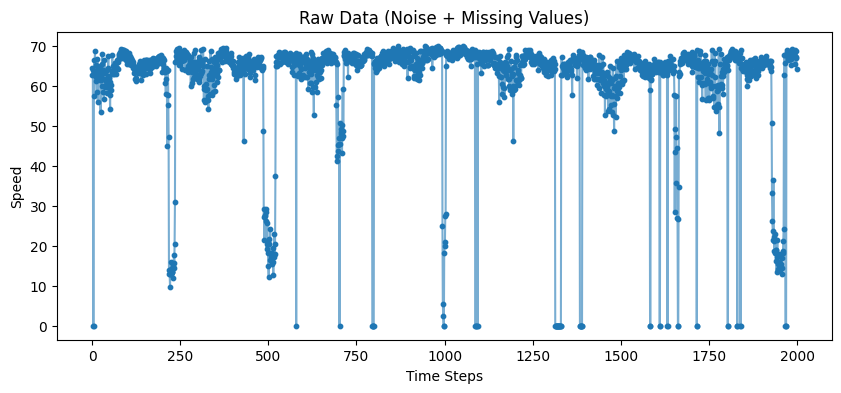

Sequence shape: (34260, 12, 207)
Epoch 1, Loss: 0.01605701446533203
Epoch 2, Loss: 0.015225017443299294
Epoch 3, Loss: 0.01154764462262392
Epoch 4, Loss: 0.011654612608253956
Epoch 5, Loss: 0.010455460287630558
Epoch 6, Loss: 0.00910395011305809
Epoch 7, Loss: 0.009181054309010506
Epoch 8, Loss: 0.007772971875965595
Epoch 9, Loss: 0.008851899765431881
Epoch 10, Loss: 0.007780809886753559
Epoch 11, Loss: 0.007044562138617039
Epoch 12, Loss: 0.007212061434984207
Epoch 13, Loss: 0.00710612628608942
Epoch 14, Loss: 0.00656864931806922
Epoch 15, Loss: 0.005977028515189886


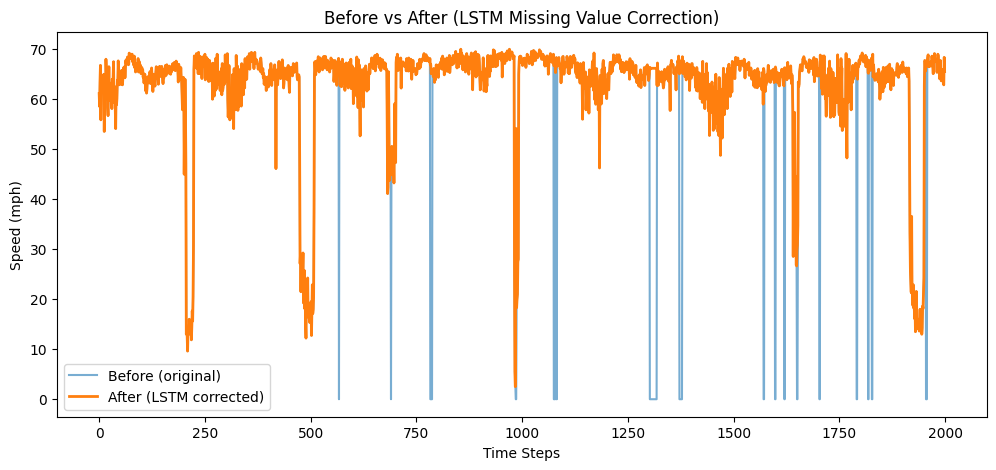

In [ ]:
# -----------------------------------------
# IMPORT LIBRARIES
# -----------------------------------------
import h5py
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset


# -----------------------------------------
# STEP 1: LOAD DATA
# -----------------------------------------
file = h5py.File('metr-la.h5', 'r')
data = file['df/block0_values'][:]

print("Dataset shape:", data.shape)


# -----------------------------------------
# STEP 2: VISUALIZATION (MISSING + NOISE)
# -----------------------------------------
sensor_id = 0

plt.figure(figsize=(10,4))
plt.plot(data[:200, sensor_id], alpha=0.6)
plt.scatter(range(200), data[:200, sensor_id], s=10)
plt.title("Raw Data (Noise + Missing Values)")
plt.xlabel("Time Steps")
plt.ylabel("Speed")
plt.show()


# -----------------------------------------
# STEP 3: CREATE MASK
# -----------------------------------------
mask = (data == 0)


# -----------------------------------------
# STEP 4: FORWARD FILL (FOR TRAINING ONLY)
# -----------------------------------------
data_fixed = data.copy()

for i in range(data.shape[1]):
    for j in range(1, data.shape[0]):
        if data_fixed[j, i] == 0:
            data_fixed[j, i] = data_fixed[j-1, i]


# -----------------------------------------
# STEP 5: NORMALIZATION
# -----------------------------------------
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data_fixed)


# -----------------------------------------
# STEP 6: CREATE SEQUENCES
# -----------------------------------------
def create_sequences(data, seq_len=12):
    sequences = []
    for i in range(len(data) - seq_len):
        sequences.append(data[i:i+seq_len])
    return np.array(sequences)

seq_len = 12
data_seq = create_sequences(data_scaled, seq_len)

print("Sequence shape:", data_seq.shape)


# -----------------------------------------
# STEP 7: DATALOADER
# -----------------------------------------
data_tensor = torch.tensor(data_seq, dtype=torch.float32)

dataset = TensorDataset(data_tensor)
loader = DataLoader(dataset, batch_size=128, shuffle=True)


# -----------------------------------------
# STEP 8: LSTM AUTOENCODER
# -----------------------------------------
class LSTMAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.LSTM(207, 128, batch_first=True)
        self.decoder = nn.LSTM(128, 207, batch_first=True)

    def forward(self, x):
        encoded, _ = self.encoder(x)
        decoded, _ = self.decoder(encoded)
        return decoded


model = LSTMAutoencoder()


# -----------------------------------------
# STEP 9: TRAIN MODEL
# -----------------------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

epochs = 15

for epoch in range(epochs):
    for batch in loader:
        x = batch[0]

        output = model(x)
        loss = loss_fn(output, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")


# -----------------------------------------
# STEP 10: RECONSTRUCTION
# -----------------------------------------
reconstructed = model(data_tensor).detach().numpy()

# ✅ FIX: take last timestep ONLY
reconstructed = reconstructed[:, -1, :]


# -----------------------------------------
# STEP 11: ALIGN ORIGINAL DATA
# -----------------------------------------
data_aligned = data[seq_len:]
mask_aligned = mask[seq_len:]


# -----------------------------------------
# STEP 12: INVERSE SCALING
# -----------------------------------------
reconstructed_original = scaler.inverse_transform(reconstructed)


# -----------------------------------------
# STEP 13: APPLY MASK (ONLY FIX 0 VALUES)
# -----------------------------------------
cleaned_data = data_aligned.copy()
cleaned_data[mask_aligned] = reconstructed_original[mask_aligned]


# -----------------------------------------
# STEP 14: FINAL VISUALIZATION
# -----------------------------------------
plt.figure(figsize=(12,5))

plt.plot(data_aligned[:200, sensor_id],
         label='Before (original)', alpha=0.6)

plt.plot(cleaned_data[:200, sensor_id],
         label='After (LSTM corrected)', linewidth=2)

plt.legend()
plt.title("Before vs After (LSTM Missing Value Correction)")
plt.xlabel("Time Steps")
plt.ylabel("Speed (mph)")
plt.show()